# Évaluation RAG — ShopVite
**Métriques** : Faithfulness + Answer Relevancy (RAGAS + Custom)


In [ ]:
!pip install ragas datasets langchain langchain-community langchain-huggingface langchain-openai faiss-cpu sentence-transformers python-dotenv --quiet

## 1. Configuration & chargement de la chaîne RAG

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

# Embedding
embedding = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

# Vectorstore
vectorstore = FAISS.load_local(
    'faiss_index',
    embeddings=embedding,
    allow_dangerous_deserialization=True
)
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

# LLM
llm = ChatOpenAI(
    base_url='https://api.mistral.ai/v1',
    api_key=os.getenv('MISTRAL_API_KEY'),
    model_name='mistral-medium',
    temperature=0.1,
)

# Prompt minimaliste pour l'éval (sans few-shot pour éviter le biais)
eval_template = """Tu es un assistant FAQ pour ShopVite.
Réponds uniquement à partir du contexte. Si absent, dis-le clairement.
Réponds en français.

CONTEXTE:
{context}

QUESTION: {question}

RÉPONSE:"""

prompt = PromptTemplate(template=eval_template, input_variables=['context', 'question'])

def format_docs(docs):
    return '\n\n'.join(
        f"[Source: {os.path.basename(doc.metadata.get('source', 'Inconnue'))}]\n{doc.page_content}"
        for doc in docs
    )

rag_chain = (
    {'context': retriever | RunnableLambda(format_docs), 'question': RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print('✅ Chaîne RAG prête.')

c:\Users\msi\anaconda3\envs\pfe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Chaîne RAG prête.


## 2. Dataset d'évaluation (12 questions avec ground truth)

In [2]:
# Dataset de 12 questions couvrant tous les cas :
# - In scope (réponse dans les docs)
# - Out of scope (hors documents)
# - Ambiguë (partiellement dans les docs)

eval_dataset = [
    {
        'question': 'Quel est le délai de rétractation chez ShopVite ?',
        'ground_truth': 'Le délai de rétractation est de 30 jours à compter de la réception du produit.',
        'category': 'in_scope'
    },
    {
        'question': 'Quels sont les modes de livraison disponibles ?',
        'ground_truth': 'ShopVite propose plusieurs modes de livraison : Standard, Express et Point Relais.',
        'category': 'in_scope'
    },
    {
        'question': 'Comment contacter le service client de ShopVite ?',
        'ground_truth': 'Le client peut contacter le service client de ShopVite via les canaux officiels mentionnés sur le site.',
        'category': 'in_scope'
    },
    {
        'question': 'Les prix affichés incluent-ils les taxes ?',
        'ground_truth': 'Oui, les prix sont indiqués en euros toutes taxes comprises (TTC), hors frais de livraison.',
        'category': 'in_scope'
    },
    {
        'question': 'Quels moyens de paiement sont acceptés ?',
        'ground_truth': 'ShopVite accepte la carte bancaire et tout autre moyen sécurisé proposé sur le site.',
        'category': 'in_scope'
    },
    {
        'question': 'Que se passe-t-il en cas de force majeure ?',
        'ground_truth': 'ShopVite ne peut être tenue responsable en cas de force majeure, incluant catastrophes naturelles, grèves, pandémies ou perturbations des réseaux.',
        'category': 'in_scope'
    },
    {
        'question': 'Puis-je retourner des écouteurs déjà ouverts ?',
        'ground_truth': 'Non, les écouteurs intra-auriculaires et produits similaires descellés ne peuvent pas être retournés pour des raisons d hygiène.',
        'category': 'in_scope'
    },
    {
        'question': 'ShopVite peut-elle modifier ses prix ?',
        'ground_truth': 'Oui, ShopVite se réserve le droit de modifier ses prix à tout moment. Le prix applicable est celui en vigueur au moment de la validation de la commande.',
        'category': 'in_scope'
    },
    {
        'question': 'Quelles garanties légales couvrent les produits ShopVite ?',
        'ground_truth': 'Les produits bénéficient de la garantie légale de conformité et de la garantie contre les vices cachés.',
        'category': 'in_scope'
    },
    {
        'question': 'Comment ShopVite traite-t-elle mes données personnelles ?',
        'ground_truth': 'Les données personnelles sont traitées conformément à la réglementation en vigueur. Le client dispose d un droit d accès, de rectification et de suppression.',
        'category': 'in_scope'
    },
    {
        'question': 'Quelle est la recette du couscous marocain ?',
        'ground_truth': 'Cette question est hors du périmètre de ShopVite. Aucune information disponible.',
        'category': 'out_of_scope'
    },
    {
        'question': 'Quel est le cours de l action Apple aujourd hui ?',
        'ground_truth': 'Cette question est hors du périmètre de ShopVite. Aucune information disponible.',
        'category': 'out_of_scope'
    },
]

print(f'Dataset : {len(eval_dataset)} questions')
print(f"  - In scope  : {sum(1 for q in eval_dataset if q['category'] == 'in_scope')}")
print(f"  - Out scope : {sum(1 for q in eval_dataset if q['category'] == 'out_of_scope')}")

Dataset : 12 questions
  - In scope  : 10
  - Out scope : 2


## 3. Génération des réponses et récupération des contextes

In [3]:
from tqdm import tqdm

results = []

for item in tqdm(eval_dataset, desc='Génération des réponses'):
    question = item['question']

    # Récupération des documents contextuels
    docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in docs]
    context_str = format_docs(docs)

    # Génération de la réponse
    answer = rag_chain.invoke(question)

    results.append({
        'question'    : question,
        'answer'      : answer,
        'contexts'    : contexts,
        'context_str' : context_str,
        'ground_truth': item['ground_truth'],
        'category'    : item['category'],
    })

print('\n✅ Réponses générées.')
for r in results[:2]:
    print(f"\nQ: {r['question']}")
    print(f"A: {r['answer'][:150]}...")

Génération des réponses: 100%|██████████| 12/12 [00:31<00:00,  2.63s/it]


✅ Réponses générées.

Q: Quel est le délai de rétractation chez ShopVite ?
A: Chez **ShopVite**, le **délai de rétractation** est de **30 jours calendaires** à compter de la date de réception du produit.

Ce délai s'applique san...

Q: Quels sont les modes de livraison disponibles ?
A: ShopVite propose trois modes de livraison :
- **Livraison Standard**
- **Livraison Express**
- **Livraison en Point Relais**

Ces options sont proposé...


## 4. Métriques Custom (sans dépendance externe)

In [4]:
from sentence_transformers import SentenceTransformer, util
import numpy as np

sim_model = SentenceTransformer('all-MiniLM-L6-v2')

def cosine_similarity_score(text_a: str, text_b: str) -> float:
    """Similarité cosinus entre deux textes via sentence-transformers."""
    emb_a = sim_model.encode(text_a, convert_to_tensor=True)
    emb_b = sim_model.encode(text_b, convert_to_tensor=True)
    return float(util.cos_sim(emb_a, emb_b))

def custom_faithfulness(answer: str, contexts: list[str]) -> float:
    """
    Faithfulness custom :
    Mesure si la réponse est sémantiquement ancrée dans les contextes.
    Score = max similarité cosinus entre la réponse et chaque chunk de contexte.
    """
    if not contexts or not answer.strip():
        return 0.0
    scores = [cosine_similarity_score(answer, ctx) for ctx in contexts]
    return float(np.max(scores))  # meilleur ancrage parmi les chunks

def custom_answer_relevancy(answer: str, question: str) -> float:
    """
    Answer Relevancy custom :
    Mesure si la réponse répond bien à la question posée.
    Score = similarité cosinus entre la réponse et la question.
    """
    if not answer.strip() or not question.strip():
        return 0.0
    return cosine_similarity_score(answer, question)

def custom_ground_truth_similarity(answer: str, ground_truth: str) -> float:
    """
    Similarité avec la ground truth (proxy de correctness).
    """
    return cosine_similarity_score(answer, ground_truth)

def out_of_scope_detection(answer: str) -> bool:
    """
    Détecte si la réponse indique correctement qu'elle est hors scope.
    """
    markers = [
        'hors', 'pas en mesure', 'ne figure pas', 'pas trouvé',
        'contacter', 'support', 'HORS_CONTEXTE', 'périmètre'
    ]
    answer_lower = answer.lower()
    return any(m.lower() in answer_lower for m in markers)

print('✅ Fonctions de métriques custom définies.')

✅ Fonctions de métriques custom définies.


In [5]:
# Calcul des métriques custom sur tous les résultats
for r in tqdm(results, desc='Calcul métriques custom'):
    r['custom_faithfulness']   = custom_faithfulness(r['answer'], r['contexts'])
    r['custom_relevancy']      = custom_answer_relevancy(r['answer'], r['question'])
    r['custom_gt_similarity']  = custom_ground_truth_similarity(r['answer'], r['ground_truth'])
    if r['category'] == 'out_of_scope':
        r['out_of_scope_ok']   = out_of_scope_detection(r['answer'])
    else:
        r['out_of_scope_ok']   = None

print('✅ Métriques custom calculées.')

Calcul métriques custom: 100%|██████████| 12/12 [00:02<00:00,  5.39it/s]

✅ Métriques custom calculées.


## 5. Évaluation RAGAS

In [6]:
try:
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from datasets import Dataset

    # Préparer le dataset RAGAS (format attendu)
    ragas_data = {
        'question' : [r['question']    for r in results],
        'answer'   : [r['answer']      for r in results],
        'contexts' : [r['contexts']    for r in results],
        'ground_truth': [r['ground_truth'] for r in results],
    }
    ragas_dataset = Dataset.from_dict(ragas_data)

    # Wrappers RAGAS
    ragas_llm   = LangchainLLMWrapper(llm)
    ragas_embed = LangchainEmbeddingsWrapper(embedding)

    # Évaluation
    ragas_result = evaluate(
        dataset=ragas_dataset,
        metrics=[faithfulness, answer_relevancy],
        llm=ragas_llm,
        embeddings=ragas_embed,
    )

    ragas_df = ragas_result.to_pandas()
    RAGAS_AVAILABLE = True
    print('✅ Évaluation RAGAS terminée.')
    print(ragas_df[['question', 'faithfulness', 'answer_relevancy']].to_string())

except Exception as e:
    RAGAS_AVAILABLE = False
    print(f'⚠️  RAGAS indisponible ({e}). Utilisation des métriques custom uniquement.')

⚠️  RAGAS indisponible (No module named 'langchain_core.pydantic_v1'). Utilisation des métriques custom uniquement.


## 6. Tableau de résultats complet

In [7]:
import pandas as pd

rows = []
for i, r in enumerate(results):
    row = {
        'N°'              : i + 1,
        'Question'        : r['question'][:60] + '...' if len(r['question']) > 60 else r['question'],
        'Catégorie'       : r['category'],
        'Faithfulness✦'   : round(r['custom_faithfulness'], 3),
        'Relevancy✦'      : round(r['custom_relevancy'], 3),
        'GT Similarity✦'  : round(r['custom_gt_similarity'], 3),
        'Hors-scope OK'   : r['out_of_scope_ok'],
    }
    # Ajout des scores RAGAS si disponibles
    if RAGAS_AVAILABLE:
        row['Faithfulness (RAGAS)'] = round(ragas_df.iloc[i]['faithfulness'], 3)
        row['Relevancy (RAGAS)']    = round(ragas_df.iloc[i]['answer_relevancy'], 3)
    rows.append(row)

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 65)
pd.set_option('display.float_format', '{:.3f}'.format)
display(df)

,N°,Question,Catégorie,Faithfulness✦,Relevancy✦,GT Similarity✦,Hors-scope OK
0,1,Quel est le délai de rétractation chez ShopVite ?,in_scope,0.709,0.759,0.727,None
1,2,Quels sont les modes de livraison disponibles ?,in_scope,0.810,0.585,0.874,None
2,3,Comment contacter le service client de ShopVite ?,in_scope,0.685,0.715,0.737,None
3,4,Les prix affichés incluent-ils les taxes ?,in_scope,0.724,0.812,0.835,None
4,5,Quels moyens de paiement sont acceptés ?,in_scope,0.717,0.497,0.696,None
5,6,Que se passe-t-il en cas de force majeure ?,in_scope,0.781,0.500,0.684,None
6,7,Puis-je retourner des écouteurs déjà ouverts ?,in_scope,0.743,0.634,0.787,None
7,8,ShopVite peut-elle modifier ses prix ?,in_scope,0.738,0.727,0.961,None
8,9,Quelles garanties légales couvrent les produits ShopVite ?,in_scope,0.837,0.757,0.741,None
9,10,Comment ShopVite traite-t-elle mes données personnelles ?,in_scope,0.754,0.634,0.697,None


## 7. Scores agrégés & synthèse

In [8]:
import numpy as np

in_scope  = [r for r in results if r['category'] == 'in_scope']
out_scope = [r for r in results if r['category'] == 'out_of_scope']

print('=' * 60)
print('  RAPPORT D ÉVALUATION RAG — ShopVite')
print('=' * 60)

print(f'\n  Questions évaluées   : {len(results)}')
print(f'  In scope             : {len(in_scope)}')
print(f'  Out of scope         : {len(out_scope)}')

print('\n── MÉTRIQUES CUSTOM (Sentence-Transformers) ──────────────')
print(f"  Faithfulness moyenne     : {np.mean([r['custom_faithfulness'] for r in in_scope]):.3f}")
print(f"  Answer Relevancy moyenne : {np.mean([r['custom_relevancy'] for r in in_scope]):.3f}")
print(f"  GT Similarity moyenne    : {np.mean([r['custom_gt_similarity'] for r in in_scope]):.3f}")

out_ok = [r for r in out_scope if r['out_of_scope_ok']]
print(f"\n  Refus hors-scope correct : {len(out_ok)}/{len(out_scope)} "
      f"({100*len(out_ok)/max(len(out_scope),1):.0f}%)")

if RAGAS_AVAILABLE:
    print('\n── MÉTRIQUES RAGAS ───────────────────────────────────────')
    print(f"  Faithfulness (RAGAS)     : {ragas_df['faithfulness'].mean():.3f}")
    print(f"  Answer Relevancy (RAGAS) : {ragas_df['answer_relevancy'].mean():.3f}")

print('\n── INTERPRÉTATION ────────────────────────────────────────')
faith_score = np.mean([r['custom_faithfulness'] for r in in_scope])
relev_score = np.mean([r['custom_relevancy'] for r in in_scope])

def interpret(score, metric):
    if score >= 0.75: return f'{metric}: EXCELLENT (>= 0.75)'
    elif score >= 0.55: return f'{metric}: BON (>= 0.55)'
    elif score >= 0.40: return f'{metric}: MOYEN (>= 0.40)'
    else: return f'{metric}: FAIBLE (< 0.40) → Revoir chunking/prompt'

print(f'  {interpret(faith_score, "Faithfulness")}')
print(f'  {interpret(relev_score, "Answer Relevancy")}')
print('=' * 60)

  RAPPORT D ÉVALUATION RAG — ShopVite

  Questions évaluées   : 12
  In scope             : 10
  Out of scope         : 2

── MÉTRIQUES CUSTOM (Sentence-Transformers) ──────────────
  Faithfulness moyenne     : 0.750
  Answer Relevancy moyenne : 0.662
  GT Similarity moyenne    : 0.774

  Refus hors-scope correct : 1/2 (50%)

── INTERPRÉTATION ────────────────────────────────────────
  Faithfulness: BON (>= 0.55)
  Answer Relevancy: BON (>= 0.55)


## 8. Visualisation

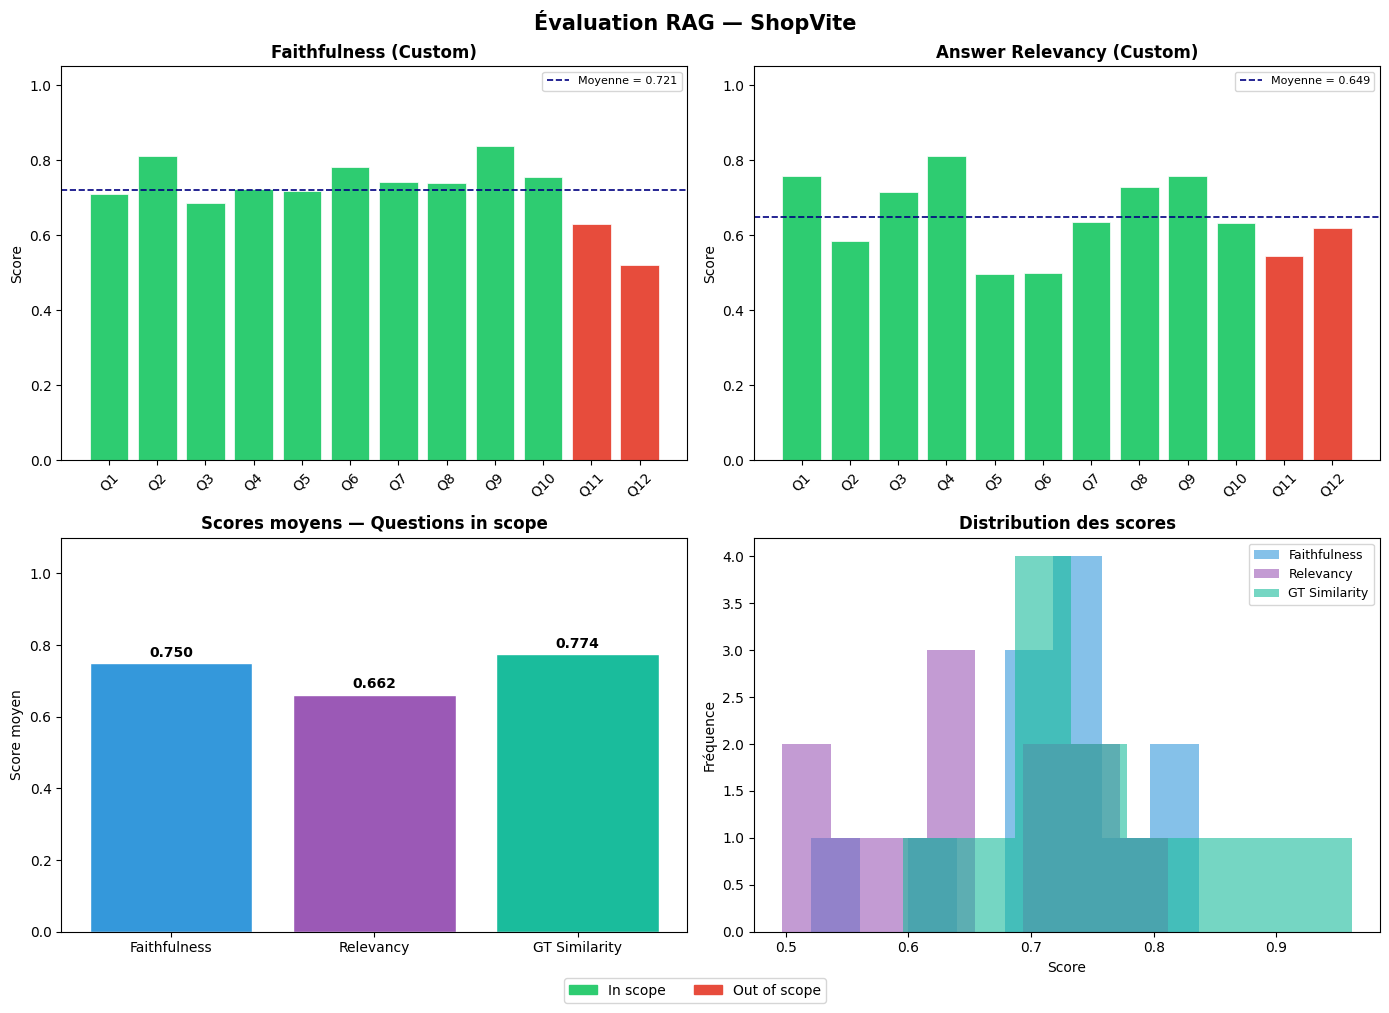

✅ Graphique sauvegardé : evaluation_results.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

questions_short = [f"Q{i+1}" for i in range(len(results))]
faith_scores  = [r['custom_faithfulness']  for r in results]
relev_scores  = [r['custom_relevancy']     for r in results]
gt_scores     = [r['custom_gt_similarity'] for r in results]
colors        = ['#2ecc71' if r['category'] == 'in_scope' else '#e74c3c' for r in results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Évaluation RAG — ShopVite', fontsize=15, fontweight='bold')

# ── Plot 1 : Faithfulness par question
ax1 = axes[0, 0]
bars = ax1.bar(questions_short, faith_scores, color=colors, edgecolor='white', linewidth=0.5)
ax1.axhline(y=np.mean(faith_scores), color='navy', linestyle='--', linewidth=1.2, label=f'Moyenne = {np.mean(faith_scores):.3f}')
ax1.set_title('Faithfulness (Custom)', fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Score')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# ── Plot 2 : Answer Relevancy par question
ax2 = axes[0, 1]
ax2.bar(questions_short, relev_scores, color=colors, edgecolor='white', linewidth=0.5)
ax2.axhline(y=np.mean(relev_scores), color='navy', linestyle='--', linewidth=1.2, label=f'Moyenne = {np.mean(relev_scores):.3f}')
ax2.set_title('Answer Relevancy (Custom)', fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Score')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=45)

# ── Plot 3 : Radar / comparaison 3 métriques
ax3 = axes[1, 0]
metrics_names  = ['Faithfulness', 'Relevancy', 'GT Similarity']
in_scope_means = [
    np.mean([r['custom_faithfulness']  for r in in_scope]),
    np.mean([r['custom_relevancy']     for r in in_scope]),
    np.mean([r['custom_gt_similarity'] for r in in_scope]),
]
bars3 = ax3.bar(metrics_names, in_scope_means, color=['#3498db', '#9b59b6', '#1abc9c'], edgecolor='white')
for bar, val in zip(bars3, in_scope_means):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Scores moyens — Questions in scope', fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.set_ylabel('Score moyen')

# ── Plot 4 : Distribution des scores
ax4 = axes[1, 1]
ax4.hist(faith_scores,  bins=8, alpha=0.6, color='#3498db', label='Faithfulness')
ax4.hist(relev_scores,  bins=8, alpha=0.6, color='#9b59b6', label='Relevancy')
ax4.hist(gt_scores,     bins=8, alpha=0.6, color='#1abc9c', label='GT Similarity')
ax4.set_title('Distribution des scores', fontweight='bold')
ax4.set_xlabel('Score')
ax4.set_ylabel('Fréquence')
ax4.legend(fontsize=9)

# Légende couleurs in/out scope
patch_in  = mpatches.Patch(color='#2ecc71', label='In scope')
patch_out = mpatches.Patch(color='#e74c3c', label='Out of scope')
fig.legend(handles=[patch_in, patch_out], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : evaluation_results.png')